In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import random
import math

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

# Module 3b Hypothesis testing

**Goals**

- Statustical Hypothesis testing conceots
- Hypothesis testing procedure
- Apply the z- and t-test

## Testing Procedure

**Definitions**

- Hypothesis | *Idea that has yet to be proven (Educated guess)*
- Hypothesis Test | *Procedure to test a hypothesis*
- Null Hypothesis | *Hypothesis that is assumed to be true (H0)*
- Alternative Hypothesis | *Hypothesis that is assumed to be false (H1, Ha)

-------------------------------------

- Test Statistic | *Value that is calculated from the sample data and used to test the null hypothesis*
- Region of Acceptance | *The region of values supporting the null hypothesis (confirm Null Hypothesis)*
- Critical Region / Region of Rejection | *The region of values rejecting the null hypothesis (confirm Alternative Hypothesis)*
- Significance Level | *The probability of rejecting a true null hypothesis (H0) (Represents the level of risk for incorrectly rejecting H0 (example is this 5%, 1% 10% chanche ??))*

## The z-test

The z-test is used to confirm or refute an assumption about the (unknown) *population mean*, based on a sufficiently large sample.

**It can only be used under specific conditions**

- The sample needs to be random
- It needs to be sifficiently large (n >= 30)
- It needs to have a normal distribution
- The standard deviation ($\sigma$) is known


## The right-tailed z-test

*If x̄ is higher $\mu$*

---------------------------------

**Procedure**

1. Formulate both hypotheses (H0 and H1)
2. Determine the significance level (α) (percentage of risk for incorrectly rejecting H0)
3. Calculate the test statistic 
4. Determine the critical value
5. Draw the conclusion

----------------------------------

**Example**

Jars of jams are filled by a machine, the normal mean is 351.2g with a standard deviation of 4.1g. It is believed there is a error.

To test this a random sample of 40 jars is taken and the mean per jar is calculated and found to be 352.8

- 𝜇 (H0) = 351.2G
- x̄ (H1) = 352.8G

![alt text](image-3.png)

**Note this plot **cannot** be used to disprove H0, either calculate the p-value or critical region**

The testing procedure then runs as follows:

- Hypothesis:
  - $H_0: \mu = 351.2$ (the machine is working correctly)
  - $H_1: \mu > 351.2$ (the machine is not working correctly)
- Significance level (α) = 0.05 (5% risk of incorrectly rejecting H0)
- Test statistic (Sample Mean) : x̄ = 351.2 (Expected result of H0)
- Determine the p-value and reject H0 if p < a (Formula used to reject or approve H0)

**Calculate p-value**

In [ ]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 352.8    # Sample mean
s_sample = sigma / math.sqrt(n)

# ----------
# CALCULATE P-VALUE [RIGHT TAILED z-test]
# ----------

alpha = 0.05 # Significance level chosen by the researcher
p = stats.norm.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n))

print("p-value: %.5f" % p)
if(p < alpha):
    print("p < alpha: reject H0")
else:
    print("p > alpha: do not reject H0")

p-value: 0.00679
p < alpha: reject H0


*Alternative method*

Determine the critical region (the set of all values for the sample mean where $H_0$ may be rejected). This boundry is called the critical value $g$. To the left you cannot reject H0 (acceptance region), to the right you can (critical region) the area of acceptance region is $1 - \alpha$ (critical region)

In [ ]:
# ----------
# CALCULATE CRITICAL VALUE [RIGHT TAILED z-test]
# ----------

# Critical value according to the formula:
#    g = mu + stats.norm.isf(alpha) * sigma / np.sqrt(n)
# Making use of the loc/scale parameters of isf:
g = stats.norm.isf(alpha, loc=mu, scale=sigma / np.sqrt(n))
print("Critical value g ≃ %.3f" % g)
if (m_sample < g):
    print("sample mean = %.3f < g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f > g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 352.266
sample mean = 352.800 > g = 352.266: reject H0


![alt text](image-9.png)

*Out of this graph we can see that x̄ falls out of the acceptance zone (blue) and can be disproved*

<details>

<summary>Show Graph code</summary>

```python
# Gauss-curve plot:
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values for the Gauss curve
dist_y = stats.norm.pdf(dist_x, mu, sigma/np.sqrt(n))
fig, dplot = plt.subplots(1, 1)
# Plot the Gauss-curve
dplot.plot(dist_x, dist_y)
# Show the hypothetical population mean with an orange line
dplot.axvline(mu, color="orange", lw=2)
# Show the sample mean with a red line
dplot.axvline(m_sample, color="red")
# Fill the acceptance area in light blue
dplot.fill_between(dist_x, 0, dist_y, where=dist_x <= g, color='lightblue');



# Add the vertical lines with labels (using actual values)
dplot.axvline(m_sample, color="red", linestyle="-", label=f"H₁: x̄ = {m_sample:.1f}")
dplot.axvline(mu, color="orange", linestyle="-", label=f"H₀: μ = {mu:.1f}")

# Add legend
dplot.legend()
```

</details>


## The left-tailed $z$-test

If we change x̄ to 350.4g, we have reasons to assume that the population mean is *lower* than the value we are testing against ($\mu$ = 351.2g). In this case we use the left-tailed


- Hypothesis:
  - $H_0: \mu = 351.2$ (the machine is working correctly)
  - <span style="color:red">**$H_1: \mu < 351.2$ (the machine is not working correctly)**</span>
- Significance level (α) = 0.05 (5% risk of incorrectly rejecting H0)
- Test statistic (Sample Mean) : x̄ = 351.2 (Expected result of H0)
- Determine the p-value and reject H0 if p < a (Formula used to reject or approve H0)


*The steps stay the same only instead of > we use < (check left instead of right)*

In [11]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean 
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 350.4    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)

# ----------
# CALCULATE P-VALUE [LEFT TAILED z-test]
# ----------

# Pay attention! Use cdf() instead of sf()! Why? cuz left side
p = stats.norm.cdf(m_sample, loc=mu, scale=sigma/np.sqrt(n)) 

print("p-value: %.5f" % p)
if(p < alpha):
    print("p < a, reject H0")
else:
    print("p > a, do not reject H0")

p-value: 0.10859
p > a, do not reject H0


**Critical Value method**

In [12]:
# Critical value according to the formula in the lecture slides
# g = m0 - stats.norm.isf(a) * s / np.sqrt(n)
# Making use of the loc/scale parameters of isf:
g = stats.norm.isf(1-alpha, loc=mu, scale=(sigma / np.sqrt(n)))
print("Critical value g ≃ %.3f" % g)
if (m_sample > g):
    print("sample mean = %.3f > g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f < g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 350.134
sample mean = 350.400 > g = 350.134: do not reject H0


![alt text](image-10.png)

*In this case we accept H0 since x̄ (red) falls within the acceptance zone*

<details>

<summary>Show Graph code</summary>

```python
# Gauss-curve:
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values
dist_y = stats.norm.pdf(dist_x, mu, sigma/np.sqrt(n))
fig, dplot = plt.subplots(1, 1)
# Plot
dplot.plot(dist_x, dist_y)
# Hypothetical population mean in orange
dplot.axvline(mu, color="orange", lw=2)
# Sample mean in red
dplot.axvline(m_sample, color="red")
# Fill the acceptance region in light blue
dplot.fill_between(dist_x, 0, dist_y, where=dist_x >= g, color='lightblue');

# Add the vertical lines with labels (using actual values)
dplot.axvline(m_sample, color="red", linestyle="-", label=f"H₁: x̄ = {m_sample:.1f}")
dplot.axvline(mu, color="orange", linestyle="-", label=f"H₀: μ = {mu:.1f}")

# Add legend
dplot.legend()
```

</details>

## The two-tailed z-test

When we don't want to know whether the population mean (𝜇) is either > (greater) or < (lower) than the hypothetical value (x̄) but only want to know when its *close enough* we use the two-tailed z-test

- Hypothesis:
  - $H_0: \mu = 351.2$
  - <span style="color:red">**$H_1: \mu != 351.2$ **</span>
- Significance level (α) = 0.05 (5% risk of incorrectly rejecting H0)
- Test statistic (Sample Mean) : x̄ = 351.2 (Expected result of H0)
- Calculate the $p$-value and reject $H_0$ if $p < \alpha/2$.

* We divide by 2 since we are interested in both directions (greater than or less than x̄)

*The steps stay the same only we use != and change step 4*


**Values**

In [16]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 351.4    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)

**Method 1 -> P-VALUE**

In [17]:
p = stats.norm.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n))
print("p-waarde: %.5f" % p)
if(p < alpha/2):
    print("p < alpha/2, reject H0")
else:
    print("p > alpha/2, do not reject H0")

p-waarde: 0.37885
p > alpha/2, do not reject H0


**Method 2 -> Critical Region**


In [18]:
g1 = mu - stats.norm.isf(alpha/2) * sigma / np.sqrt(n)
g2 = mu + stats.norm.isf(alpha/2) * sigma / np.sqrt(n)

print("Acceptance region [g1, g2] ≃ [%.3f, %.3f]" % (g1,g2))
if (g1 < m_sample and m_sample < g2):
    print("Sample mean = %.3f is inside acceptance region: do not reject H0" % m_sample)
else:
    print("Sample mean = %.3f is outside acceptance region: reject H0" % m_sample)

Acceptance region [g1, g2] ≃ [349.929, 352.471]
Sample mean = 351.400 is inside acceptance region: do not reject H0


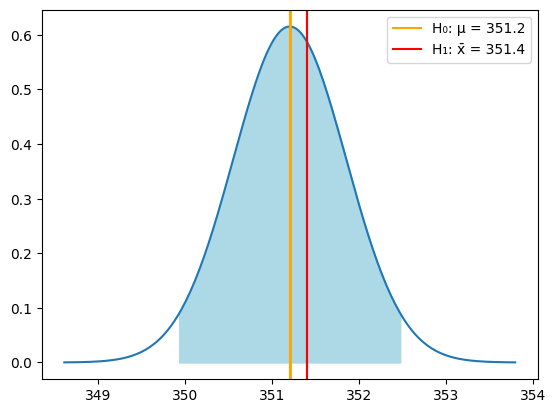

*We cannot reject H0 since x̄ appears within the acceptance zone*

<details>

<summary>Show Graph code</summary>

```python
# Gauss-curve
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values
dist_y = stats.norm.pdf(dist_x, loc=mu, scale=sigma/np.sqrt(n))
fig, dplot = plt.subplots(1, 1)
# Plot
dplot.plot(dist_x, dist_y)
# Hypothetical population mean in orange
dplot.axvline(mu, color="orange", lw=2)
# Sample mean in red
dplot.axvline(m_sample, color="red")
acc_x = np.linspace(g1, g2, num=101)
acc_y = stats.norm.pdf(acc_x, loc=mu, scale=sigma/np.sqrt(n))
# Fill the acceptance region in light blue
dplot.fill_between(acc_x, 0, acc_y, color='lightblue');
# Add the vertical lines with labels (using actual values)
dplot.axvline(mu, color="orange", linestyle="-", label=f"H₀: μ = {mu:.1f}")
dplot.axvline(m_sample, color="red", linestyle="-", label=f"H₁: x̄ = {m_sample:.1f}")

# Add legend
dplot.legend()

plt.show()
```


</details>

## Student's t-test

In case that the sample is small, $\sigma$ is unknown, etc...

We use the Student's t-test

Example:

Testing wether the pulse of trained atletes is lower than young healthy adults.

A random samples of 12 trained athletes is taken

We sill test with a 5% significance (fault tolerance)

- Hypothesis:
  - $H_0: \mu = 80$ (the pulse of trained ahletes are the same as young healthy adults)
  -$H_1: \mu < 80.$ (the pulse of trained ahletes are lower as young healthy adults)
- Significance level (α) = 0.05 (5% risk of incorrectly rejecting H0)
- Test statistic (Sample Mean) : x̄ = 52.33 (Expected result of H0)
- Determine the p-value and reject H0 if p < a (Formula used to reject or approve H0)


**Method 1 -> P-Value**

In [ ]:
# ----------
# VALUES
# ----------

pulses = [48, 52, 59, 45, 57, 52, 44, 58, 56, 44, 63, 50]
n = len(pulses)
mu = 80
m_sample = np.mean(pulses)
s_sample = np.std(pulses,ddof=1)
alpha = 0.05

# CALCULATE SAMPLE MEAN
print(f"Sample mean: {m_sample:.2f}") 

#CALCULATE P-VALUE
p = stats.t.cdf(m_sample, loc = mu, scale = s_sample / math.sqrt(n), df = n - 1)
print(f"p-value: {p}")
if(p < alpha):
    print("p < alpha: reject H0")
else:
    print("p > alpha: do not reject H0")

Sample mean: 52.33
p-value: 5.283891352937751e-09
p < alpha: reject H0


**Method 2 -> critical region**

In [21]:
g = stats.t.isf(1-alpha, loc = mu, scale = s_sample / math.sqrt(n), df = n - 1)
print("Critical value g ≃ %.3f" % g)
if (m_sample > g):
    print("sample mean = %.3f > g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f < g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 76.711
sample mean = 52.333 < g = 76.711: reject H0


![alt text](image-6.png)

*As shown on the plot the pulse rate of trained atletes is outside of the acceptance region, while the p value is also significantly lower. We can reject $H_0$*

<details>
<summary>Show Graph code</summary>

```python
# Gauss-curve
dist_x = np.linspace(50, 90, num=201)
dist_y = stats.t.pdf(dist_x, loc=mu, scale=s_sample/np.sqrt(n), df=n-1)
fig, dplot = plt.subplots(1, 1)

# Plot
dplot.plot(dist_x, dist_y)
# Hypothetical population mean in orange
dplot.axvline(mu, color="orange", lw=2)
# Sample mean in red
dplot.axvline(m_sample, color="red")
# Fill the acceptance region in light blue
dplot.fill_between(dist_x, 0, dist_y, where=dist_x >= g, color='lightblue')

# Add the vertical lines with labels (using actual values)
dplot.axvline(m_sample, color="red", linestyle="-", label=f"H₁: x̄ = {m_sample:.1f}")
dplot.axvline(mu, color="orange", linestyle="-", label=f"H₀: μ = {mu:.1f}")

# Add legend
dplot.legend()

plt.show()
```

</details>

### Two-tailed t-test

In [ ]:
pulses = [48, 52, 59, 45, 57, 52, 44, 58, 56, 44, 63, 50]
alpha = 0.05
mu = 80

t_stat, p_val = stats.ttest_1samp(a=pulses, popmean=mu, alternative='less')
print("Sample mean        : %.3f" % np.mean(pulses))
print("t-score            : %.3f" % t_stat)
print(f"p-value           : {p_val}")

Identical results to what we obtained earlier. there is no simular fonction for the z-test (rarely used in the real world). The t-test is more versatile and can be used in a wider range of situations

## Errors in Hypothesis Tests

**Type I error** (false positive)  
The null hypothesis is actually true and you reject it.  

P(type I error) = 𝛼 (= significance level)  


**Type II error** (false negative)    
You accept the null hypothesis and it was not true 

P(type II error) = 𝛽  

*Calculating 𝛽 is not trivial, but if 𝛼 ↘ then 𝛽 ↗*

## Extras

**Calculate n using**

In [26]:
def calculate_n(z_score):
    """
    Calculate sample size n using:
    z = (x_bar - mu) / (s / sqrt(n))
    Given:
    z = 1.867
    x_bar = 75.2
    mu = 74.0
    s = 5.3
    Returns n as a float.
    """
    
    mu = 74.0          # (Hypothetical) population mean 

    n = (sigma / ((m_sample - mu) / z_score)) ** 2
    return n

# Usage:

# Properties of the sample:
n = calculate_n(1.867) # Calculate N using the z-score
mu = 74.0          # (Hypothetical) population mean 
sigma = 5.3        # Population standard deviation (assumed to be known)
m_sample = 75.2    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)


print(f"Calculated n: {n:.0f}")

Calculated n: 68


**Alternative calculate n**

In [ ]:
# Properties of the sample:
mu = 74.0          # (Hypothetical) population mean 
sigma = 5.3        # Population standard deviation (assumed to be known)
m_sample = 75.2    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)

z_score = 1.867

for n in range(1,100):
    formula = (m_sample - mu) / (sigma / np.sqrt(n))

    if np.isclose(formula, z_score, atol=0.01):
        print(n)

In [27]:
def calculate_z_score(m_sample, mu, sigma, n):
    """
    Calculates the z-score for a sample mean.
    z = (m_sample - mu) / (sigma / sqrt(n))
    """
    return (m_sample - mu) / (sigma / n**0.5)

# Example usage:
n = 68              # Sample size
mu = 74.0            # Population mean
sigma = 5.3          # Population standard deviation
m_sample = 75.2      # Sample mean

z = calculate_z_score(m_sample, mu, sigma, n)
print(f"z-score: {z:.3f}")

# Explanation:
# The z-score measures how many standard errors the sample mean is away from the population mean.
# It is used in hypothesis testing to determine if the observed sample mean is significantly different from the population mean.

z-score: 1.867
